In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import scienceplots
plt.style.use(["science"])
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "axes.labelsize": 19,    # x- and y-label size
    "axes.titlesize": 20,    # title size
    "xtick.labelsize": 14,   # x-tick label size
    "ytick.labelsize": 14,   # y-tick label size
    "legend.fontsize": 18,   # legend text size
})


# FUNCTIONS

In [3]:
def csch2(z):
    s = np.sinh(z)
    return 1.0 / (s * s)

def exact_steady_state(gamma, alpha1, alpha2, Omega_S, Temp, Nmats=50000):
    """
    Calculates the exact analytical steady-state position and momentum variances 
    using the Residue Theorem in the frequency domain.
    """
    beta = 1.0 / Temp
    pref = gamma**2 * alpha1 * alpha2
    
    # 1. Define Polynomial A(s) and find its roots and derivative
    A_poly = np.poly1d([1, gamma, alpha2 * gamma + Omega_S**2, 
                        gamma * Omega_S**2, alpha2 * gamma * Omega_S**2 - gamma * alpha1 * alpha2])
    A_deriv = np.polyder(A_poly)
    roots_p = np.roots(A_poly)
    
    # 2. Sum the System Residues (4 dynamical poles)
    sys_sum_x, sys_sum_p = 0j, 0j
    for p in roots_p:
        term_x = (pref * p) / (A_poly(-p) * A_deriv(p)) * (1.0 / np.tan(beta * p / 2.0))
        sys_sum_x += term_x
        sys_sum_p += (-p**2) * term_x
        
    # 3. Sum the Matsubara Residues (Thermal bath poles)
    k = np.arange(1, Nmats + 1)
    nu_k = (2 * np.pi / beta) * k
    mats_terms_x = (-2 * nu_k * pref) / (beta * A_poly(nu_k) * A_poly(-nu_k))
    
    mats_sum_x = np.sum(mats_terms_x)
    mats_sum_p = np.sum((-nu_k**2) * mats_terms_x)
    
    var_x_ss = np.real(sys_sum_x + mats_sum_x)
    var_p_ss = np.real(sys_sum_p + mats_sum_p)
    
    return var_x_ss, var_p_ss

def get_sigma_and_deriv(gamma, alpha1, alpha2, Omega_S, Temp, dT=1e-12, Nmats=50000):
    """Calculates steady-state covariance and its temperature derivative via central difference."""
    var_x, var_p = exact_steady_state(gamma, alpha1, alpha2, Omega_S, Temp, Nmats)
    sigma = np.array([[var_x, 0.0], [0.0, var_p]])
    
    # +/- dT for central finite difference
    var_x_plus, var_p_plus = exact_steady_state(gamma, alpha1, alpha2, Omega_S, Temp + dT, Nmats)
    var_x_minus, var_p_minus = exact_steady_state(gamma, alpha1, alpha2, Omega_S, Temp - dT, Nmats)
    
    dsigma = np.array([
        [(var_x_plus - var_x_minus) / (2 * dT), 0.0],
        [0.0, (var_p_plus - var_p_minus) / (2 * dT)]
    ])
    return sigma, dsigma


def calc_classical_CFI(sig, dsig, sig_M):
    inv_term = np.linalg.inv(sig + sig_M)
    prod = np.dot(inv_term, dsig)
    return 0.5 * np.trace(np.dot(prod, prod))

# --- NEW: Helper function for On/Off Photodetection CFI ---
def calc_rpd_CFI(sig, dsig, sig_vac, P_D=0.0):
    A = sig + sig_vac
    det_A = np.linalg.det(A)
    inv_A = np.linalg.inv(A)
    trace_term = np.trace(np.dot(inv_A, dsig))
    
    P_0 = (1.0 - P_D) / np.sqrt(det_A)
    dP_0 = -0.5 * P_0 * trace_term
    
    return (dP_0**2) / (P_0 * (1.0 - P_0) + 1e-15)

def calc_QFI(sigma, dsigma):
    # --- 3. Quantum FI (Using Analytical Formula from Appendix B) ---
                    
    # 3.a) Calculate determinants explicitly for 2x2 matrices
    det_sigma = sigma[0,0]*sigma[1,1] - sigma[0,1]**2
    det_dsigma = dsigma[0,0]*dsigma[1,1] - dsigma[0,1]**2
    
    # 3.b) Calculate the temperature derivative of the determinant (Eq. B15)
    d_det_sigma = dsigma[0,0]*sigma[1,1] + sigma[0,0]*dsigma[1,1] - 2*sigma[0,1]*dsigma[0,1]
    
    # 3.c) Apply Eq. (B20)
    # We use a tiny epsilon max-gate to prevent strict ZeroDivision at exactly t=0
    # since det_sigma approaches 0.25 for pure states.
    epsilon = 1e-16 
    purity_term = np.maximum(det_sigma - 0.25, epsilon)
    
    term1 = 0.5 * (d_det_sigma**2) / (purity_term * (det_sigma + 0.25))
    term2 = det_dsigma / (det_sigma + 0.25)
    
    QFI = term1 - term2 
    return QFI

# EXACT STEADY STATE COVARIANCE MATRIX

In [14]:
if __name__ == "__main__":
    # Parameters from your dynamical simulation
    gamma = 1.0
    alpha1 = 0.1
    alpha2 = 10.0
    Omega_S_bare = 1.0
    temp = 0.0001
    
    # Calculate physical system frequency including the bath shift
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    print("--- Calculating Exact Steady State ---")
    print(f"Parameters: T={temp}, gamma={gamma}, alpha1={alpha1}, alpha2={alpha2}, Omega_S={Omega_S:.4f}")
    
    # Call the exact function
    var_x_ss, var_p_ss = exact_steady_state(gamma, alpha1, alpha2, Omega_S, temp, Nmats=30000)
    
    print("\nResults:")
    print(f"<x_S^2>_ss = {var_x_ss:.6f}")
    print(f"<p_S^2>_ss = {var_p_ss:.6f}")
    
    # Form the steady-state covariance matrix
    # The cross-term <{x, p}>_ss is always exactly 0 at steady state
    sigma_ss = np.array([
        [var_x_ss, 0.0],
        [0.0, var_p_ss]
    ])
    
    print("\nExact Steady-State Covariance Matrix:")
    print(np.array2string(sigma_ss, precision=6, suppress_small=True))
    
    # Sanity Check: Purity limit
    det_sigma = np.linalg.det(sigma_ss)
    print(f"\nDeterminant det(sigma) = {det_sigma:.6f}")
    if det_sigma >= 0.25:
        print("-> Physics Check: PASS (det >= 0.25, valid quantum state)")
    else:
        print("-> Physics Check: FAIL (det < 0.25, violates uncertainty principle)")

--- Calculating Exact Steady State ---
Parameters: T=0.0001, gamma=1.0, alpha1=0.1, alpha2=10.0, Omega_S=1.0488

Results:
<x_S^2>_ss = 0.497500
<p_S^2>_ss = 0.511950

Exact Steady-State Covariance Matrix:
[[0.4975  0.     ]
 [0.      0.51195]]

Determinant det(sigma) = 0.254695
-> Physics Check: PASS (det >= 0.25, valid quantum state)


C:\Users\usuario\AppData\Local\Temp\ipykernel_8896\998661463.py:22: RuntimeWarning: overflow encountered in tan
  term_x = (pref * p) / (A_poly(-p) * A_deriv(p)) * (1.0 / np.tan(beta * p / 2.0))


# EXACT VARIANCES vs WEAKLY COUPLED (T)


--- Running Temperature Sweep for Plotting ---


C:\Users\alber\AppData\Local\Temp\ipykernel_22084\2980120071.py:22: RuntimeWarning: overflow encountered in tan
  term_x = (pref * p) / (A_poly(-p) * A_deriv(p)) * (1.0 / np.tan(beta * p / 2.0))



--- Running Alpha_1 Sweep for Insets ---


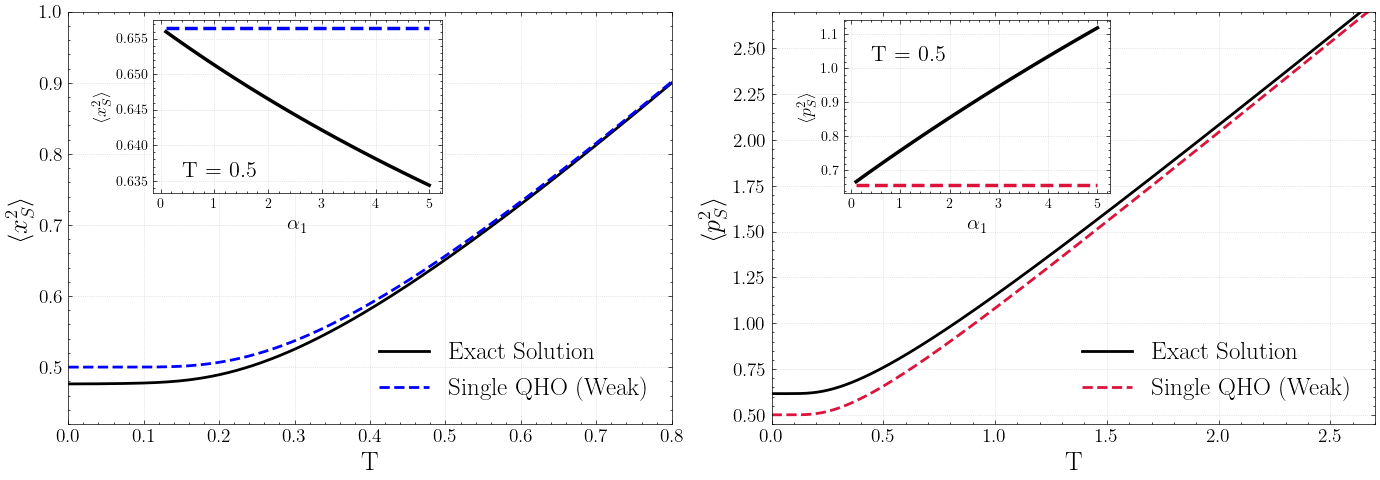

In [52]:

if __name__ == "__main__":
    gamma = 1.0
    alpha1_main = 1
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1_main)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
        
    print("\n--- Running Temperature Sweep for Plotting ---")
    
    # --- 2. TEMPERATURE SWEEP ---
    temperatures = np.linspace(0.0001, 3.0, 5000)
    var_x_exact = np.zeros_like(temperatures)
    var_p_exact = np.zeros_like(temperatures)
    for i, T in enumerate(temperatures):
        vx, vp = exact_steady_state(gamma, alpha1_main, alpha2, Omega_S, T, Nmats=30000)
        var_x_exact[i] = vx
        var_p_exact[i] = vp
        
        det_sigma = vx * vp
        if det_sigma < 0.2499:
            print(f"WARNING at T={T:.2f}: det(sigma) = {det_sigma:.4f} < 0.25! (Unphysical)")
            
    # --- SINGLE QUANTUM HARMONIC OSCILLATOR COMPARISON ---
    coth_factor = 1.0 / np.tanh(Omega_S_bare / (2.0 * temperatures))
    var_x_sho = (1.0 / (2.0 * Omega_S_bare)) * coth_factor
    var_p_sho = (Omega_S_bare / 2.0) * coth_factor

    # --- 3. ALPHA_1 SWEEP FOR INSETS ---
    print("\n--- Running Alpha_1 Sweep for Insets ---")
    T_inset = 0.5 
    alphas = np.linspace(0.1, 5.0, 50)
    var_x_alpha = np.zeros_like(alphas)
    var_p_alpha = np.zeros_like(alphas)
    
    # <--- NEW: Initialize the SHO inset arrays before the loop
    var_x_sho_ins = np.zeros_like(alphas)
    var_p_sho_ins = np.zeros_like(alphas)
    
    for i, a1 in enumerate(alphas):
        # The exact solution still needs Omega_S_eff to properly cancel a1 inside the function
        Omega_S_eff = np.sqrt(Omega_S_bare**2 + a1)
        vx, vp = exact_steady_state(gamma, a1, alpha2, Omega_S_eff, T_inset, Nmats=20000)
        var_x_alpha[i] = vx
        var_p_alpha[i] = vp
        
        # The SHO reference is completely independent of a1; it just uses the physical bare frequency
        coth_factor_ins = 1.0 / np.tanh(Omega_S_bare / (2.0 * T_inset))
        var_x_sho_ins[i] = (1.0 / (2.0 * Omega_S_bare)) * coth_factor_ins
        var_p_sho_ins[i] = (Omega_S_bare / 2.0) * coth_factor_ins

    # --- 4. PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left Plot: Position
    ax1.plot(temperatures, var_x_exact, 'k-', lw=2, label=r'Exact Solution')
    ax1.plot(temperatures, var_x_sho, 'b--', lw=2, label=r'Single QHO (Weak)')
    ax1.set_xlabel('T')
    ax1.set_ylabel(r'$\langle x_S^2 \rangle$')
    ax1.set_xlim(0, 0.8)
    ax1.set_ylim(0.42, 1)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Left Plot Inset: Position vs Alpha
    # Coordinates for inset: [x0, y0, width, height] as fractions of ax1
    axins1 = ax1.inset_axes([0.14, 0.56, 0.48, 0.42])
    axins1.plot(alphas, var_x_alpha, 'k-', lw=2.5)
    axins1.plot(alphas, var_x_sho_ins, 'b--', lw=2.5)
    axins1.set_xlabel(r'$\alpha_1$', fontsize=15)
    axins1.set_ylabel(r'$\langle x_S^2 \rangle$', fontsize=13)
    axins1.tick_params(axis='both', which='major', labelsize=10)
    axins1.text(0.1, 0.18, f"T = {T_inset}", transform=axins1.transAxes, 
                    fontsize=16, verticalalignment='top')
    axins1.grid(True, linestyle=':', alpha=0.6)

    # Right Plot: Momentum
    ax2.plot(temperatures, var_p_exact, 'k-', lw=2, label=r'Exact Solution')
    ax2.plot(temperatures, var_p_sho, '--', color='crimson', lw=2, label=r'Single QHO (Weak)')
    ax2.set_xlabel('T')
    ax2.set_ylabel(r'$\langle p_S^2 \rangle$')
    ax2.set_xlim(0, 2.7)
    ax2.set_ylim(0.45, 2.7)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # Right Plot Inset: Momentum vs Alpha
    axins2 = ax2.inset_axes([0.12, 0.56, 0.44, 0.42])
    axins2.plot(alphas, var_p_alpha, 'k-', lw=2.5)
    axins2.plot(alphas, var_p_sho_ins, '--', color='crimson', lw=2.5)
    axins2.set_xlabel(r'$\alpha_1$', fontsize=15)
    axins2.set_ylabel(r'$\langle p_S^2 \rangle$', fontsize=13)
    axins2.tick_params(axis='both', which='major', labelsize=10)
    axins2.text(0.1, 0.85, f"T = {T_inset}", transform=axins2.transAxes, 
                fontsize=16, verticalalignment='top')
    axins2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# STEADY STATE CFI & QFI

Sweeping Temperatures...


100%|██████████| 3000/3000 [00:16<00:00, 178.36it/s]


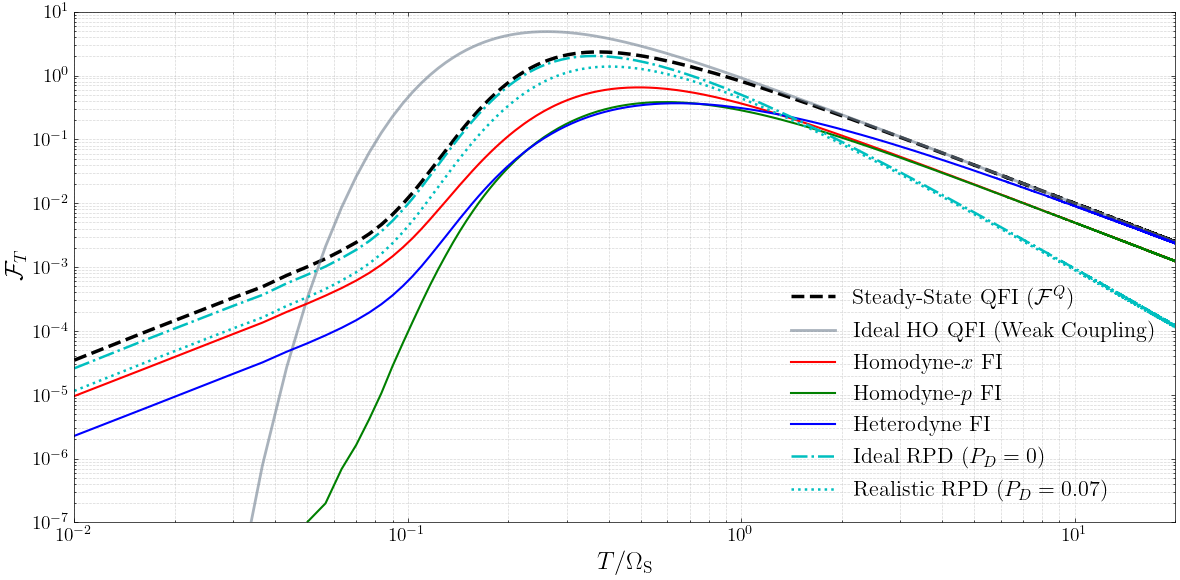

In [5]:
if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha1 = 1
    alpha2 = 10.0
    Omega_S_bare = 1.0
    delta_Omega_s = np.sqrt(alpha1)
    Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2)
    
    # --- Temperature Grid ---
    T_vals = np.linspace(0.01, 20, 3000)
    
    # Measurement Matrices (sig_M_het acts as vacuum covariance for RPD)
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-6, 0.0], [0.0, 1e6]])
    sig_M_hom_p = np.array([[1e6, 0.0], [0.0, 1e-6]])

    # Data arrays
    FI_het = np.zeros_like(T_vals)
    FI_hom_x = np.zeros_like(T_vals)
    FI_hom_p = np.zeros_like(T_vals)
    FI_rpd_ideal = np.zeros_like(T_vals)  # <-- Added
    FI_rpd_real = np.zeros_like(T_vals)   # <-- Added
    QFI = np.zeros_like(T_vals)
    QFI_HO = np.zeros_like(T_vals) 

    print("Sweeping Temperatures...")
    for i, T in enumerate(tqdm(T_vals)):
        # 1. Get Exact Steady State and its T-Derivative
        sigma_ss, dsigma_ss = get_sigma_and_deriv(gamma, alpha1, alpha2, Omega_S, T)
        
        # 2. Calculate FIs
        FI_het[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_het)
        FI_hom_x[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_hom_x)
        FI_hom_p[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_hom_p)
        
        # --- Calculate Photodetection FIs ---
        FI_rpd_ideal[i] = calc_rpd_CFI(sigma_ss, dsigma_ss, sig_M_het, P_D=0.0)
        FI_rpd_real[i]  = calc_rpd_CFI(sigma_ss, dsigma_ss, sig_M_het, P_D=0.05)
        
        QFI[i] = calc_QFI(sigma_ss, dsigma_ss)
        
        # 3. Calculate Reference Ideal Harmonic Oscillator QFI
        QFI_HO[i] = 0.25 * (Omega_S_bare**2 / T**4) * csch2(Omega_S_bare / (2*T))

    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    plt.plot(T_vals, QFI, color='black', linestyle='--', linewidth=2.5, label=r"Steady-State QFI ($\mathcal{F}^Q$)")
    plt.plot(T_vals, QFI_HO, color='slategray', linestyle='-', alpha=0.6, linewidth=2, label=r"Ideal HO QFI (Weak Coupling)")
    
    plt.plot(T_vals, FI_hom_x, color='red', linewidth=1.5, label=r"Homodyne-$x$ FI")
    plt.plot(T_vals, FI_hom_p, color='green', linewidth=1.5, label=r"Homodyne-$p$ FI")
    plt.plot(T_vals, FI_het, color='blue', linewidth=1.5, label=r"Heterodyne FI")
    
    # --- Plot Photodetection Lines ---
    plt.plot(T_vals, FI_rpd_ideal, color='c', linewidth=1.8, linestyle='-.', label=r"Ideal RPD ($P_D=0$)")
    plt.plot(T_vals, FI_rpd_real, color='c', linewidth=1.8, linestyle=':', label=r"Realistic RPD ($P_D=0.07$)")
    
    # Using a logarithmic axis because FI diverges/changes rapidly near T=0
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel(r"$T/\Omega_{\textrm{S}}$", fontsize=18)
    plt.ylabel(r"$\mathcal{F}_T$", fontsize=18)
    plt.xlim([T_vals[0], T_vals[-1]])
    plt.ylim(1e-7, 10)
    
    plt.legend(loc='lower right', fontsize=16)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Steady State QFI for alpha1

Sweeping Temperatures for alpha1 = 0.1...


  0%|          | 0/2000 [00:00<?, ?it/s]C:\Users\usuario\AppData\Local\Temp\ipykernel_21832\2980120071.py:22: RuntimeWarning: overflow encountered in tan
  term_x = (pref * p) / (A_poly(-p) * A_deriv(p)) * (1.0 / np.tan(beta * p / 2.0))
100%|██████████| 2000/2000 [00:28<00:00, 71.20it/s]


Sweeping Temperatures for alpha1 = 1.0...


100%|██████████| 2000/2000 [00:27<00:00, 72.55it/s]


Sweeping Temperatures for alpha1 = 1000...


100%|██████████| 2000/2000 [00:23<00:00, 83.50it/s] 


Sweeping Temperatures for alpha1 = 100000...


100%|██████████| 2000/2000 [00:27<00:00, 73.78it/s]


Sweeping Temperatures for alpha1 = 1000000...


100%|██████████| 2000/2000 [00:26<00:00, 75.95it/s]
C:\Users\usuario\AppData\Local\Temp\ipykernel_21832\2980120071.py:3: RuntimeWarning: overflow encountered in scalar multiply
  return 1.0 / (s * s)


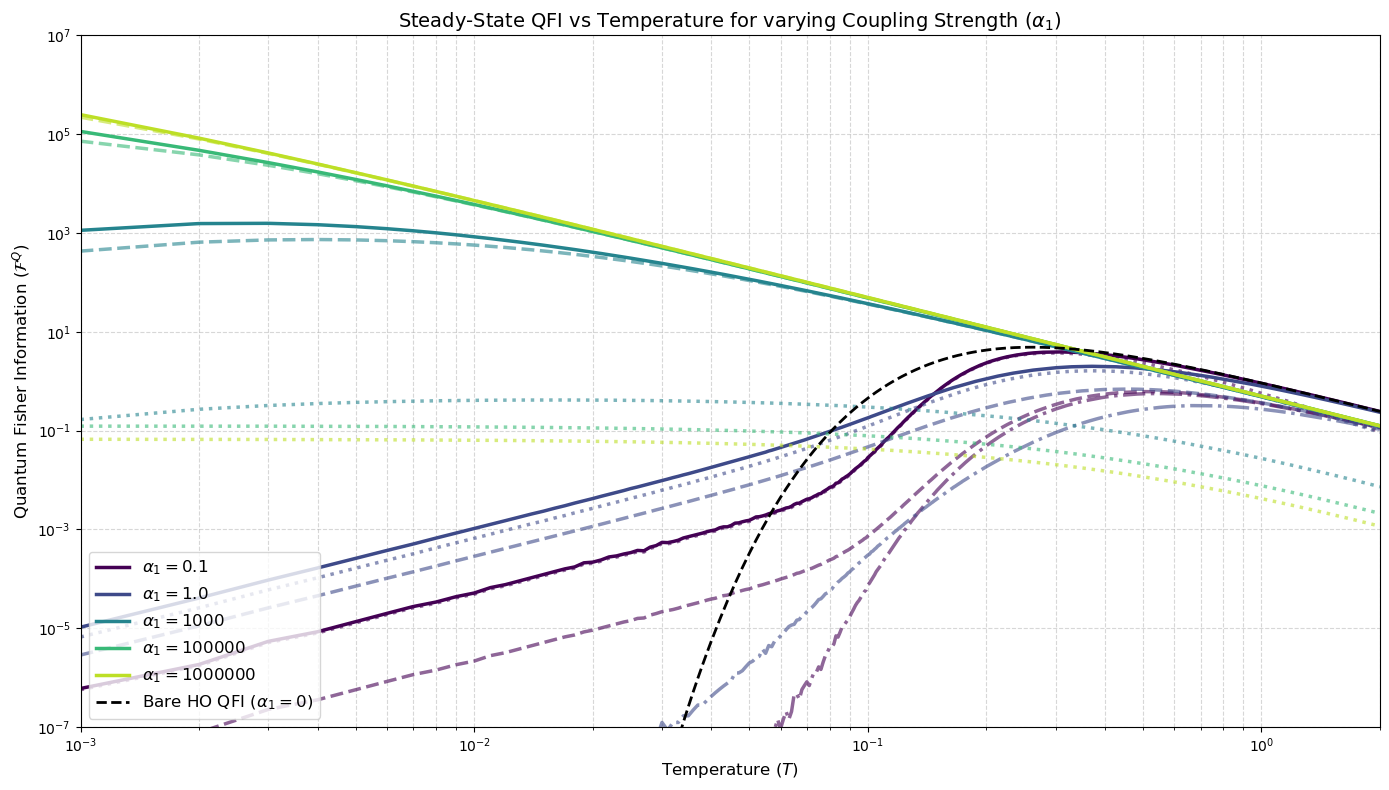

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.cm as cm

if __name__ == "__main__":
    # --- Physical Parameters ---
    gamma = 1.0
    alpha2 = 2.0
    Omega_S_bare = 1.0
    
    # --- Sweeping Parameters ---
    # Define the range of alpha1 values to test
    alpha1_vals = [0.1, 1.0, 1000, 100000, 1000000]
    
    # --- Temperature Grid ---
    T_vals = np.linspace(0.001, 2, 2000)

    # Measurement Matrices (sig_M_het acts as vacuum covariance for RPD)
    sig_M_het = np.array([[0.5, 0.0], [0.0, 0.5]])
    sig_M_hom_x = np.array([[1e-8, 0.0], [0.0, 1e8]])
    sig_M_hom_p = np.array([[1e8, 0.0], [0.0, 1e-8]])

    # Data arrays
    FI_het = np.zeros_like(T_vals)
    FI_hom_x = np.zeros_like(T_vals)
    FI_hom_p = np.zeros_like(T_vals)
    FI_rpd_ideal = np.zeros_like(T_vals)  # <-- Added
    FI_rpd_real = np.zeros_like(T_vals)   # <-- Added
    QFI = np.zeros_like(T_vals)
    QFI_HO = np.zeros_like(T_vals) 

    plt.figure(figsize=(14, 8))
    
    # Generate distinct colors for each alpha1 line
    colors = cm.viridis(np.linspace(0, 0.9, len(alpha1_vals)))

    for idx, alpha1 in enumerate(alpha1_vals):
        # Update effective frequency based on current alpha1
        delta_Omega_s = np.sqrt(alpha1)
        Omega_S = np.sqrt(Omega_S_bare**2 + delta_Omega_s**2) 
        
        print(f"Sweeping Temperatures for alpha1 = {alpha1}...")
        for i, T in enumerate(tqdm(T_vals)):
            # 1. Get Exact Steady State and its T-Derivative
            sigma_ss, dsigma_ss = get_sigma_and_deriv(gamma, alpha1, alpha2, Omega_S, T)
            
            # 2. Calculate QFI
            QFI[i] = calc_QFI(sigma_ss, dsigma_ss)

            # 2. Calculate FIs
            FI_het[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_het)
            FI_hom_x[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_hom_x)
            FI_hom_p[i] = calc_classical_CFI(sigma_ss, dsigma_ss, sig_M_hom_p)
            
            # --- Calculate Photodetection FIs ---
            FI_rpd_ideal[i] = calc_rpd_CFI(sigma_ss, dsigma_ss, sig_M_het, P_D=0.0)
            FI_rpd_real[i]  = calc_rpd_CFI(sigma_ss, dsigma_ss, sig_M_het, P_D=0.05)
            
        # Plot the QFI for this specific alpha1
        plt.plot(T_vals, QFI, color=colors[idx], linewidth=2.5, label=rf"$\alpha_1 = {alpha1}$")
        plt.plot(T_vals, FI_hom_x, color=colors[idx], linewidth=2.5, linestyle='--', alpha = 0.6)
        plt.plot(T_vals, FI_hom_p, color=colors[idx], linewidth=2.5, linestyle='-.', alpha = 0.6)
        plt.plot(T_vals, FI_rpd_ideal, color=colors[idx], linewidth=2.5, linestyle=':', alpha = 0.6)


    # --- Calculate Reference Ideal Harmonic Oscillator QFI (Bare System) ---
    # We use Omega_S_bare here to show the baseline without bath renormalization
    QFI_HO_bare = np.zeros_like(T_vals)
    for i, T in enumerate(T_vals):
        QFI_HO_bare[i] = 0.25 * (Omega_S_bare**2 / T**4) * csch2(Omega_S_bare / (2*T))
        
    plt.plot(T_vals, QFI_HO_bare, color='black', linestyle='--', linewidth=2, label=r"Bare HO QFI ($\alpha_1=0$)")

    # --- Plotting formatting ---
    # Using a logarithmic axis because FI diverges/changes rapidly near T=0
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Temperature ($T$)", fontsize=12)
    plt.ylabel(r"Quantum Fisher Information ($\mathcal{F}^Q$)", fontsize=12)
    plt.title(r"Steady-State QFI vs Temperature for varying Coupling Strength ($\alpha_1$)", fontsize=14)
    plt.xlim([T_vals[0], T_vals[-1]])
    plt.ylim(1e-7, 1e7)
    
    plt.legend(loc='lower left', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


--- Running Temperature Sweep for Plotting ---


C:\Users\alber\AppData\Local\Temp\ipykernel_22084\2980120071.py:22: RuntimeWarning: overflow encountered in tan
  term_x = (pref * p) / (A_poly(-p) * A_deriv(p)) * (1.0 / np.tan(beta * p / 2.0))



--- Running Alpha_1 Sweep for Insets ---


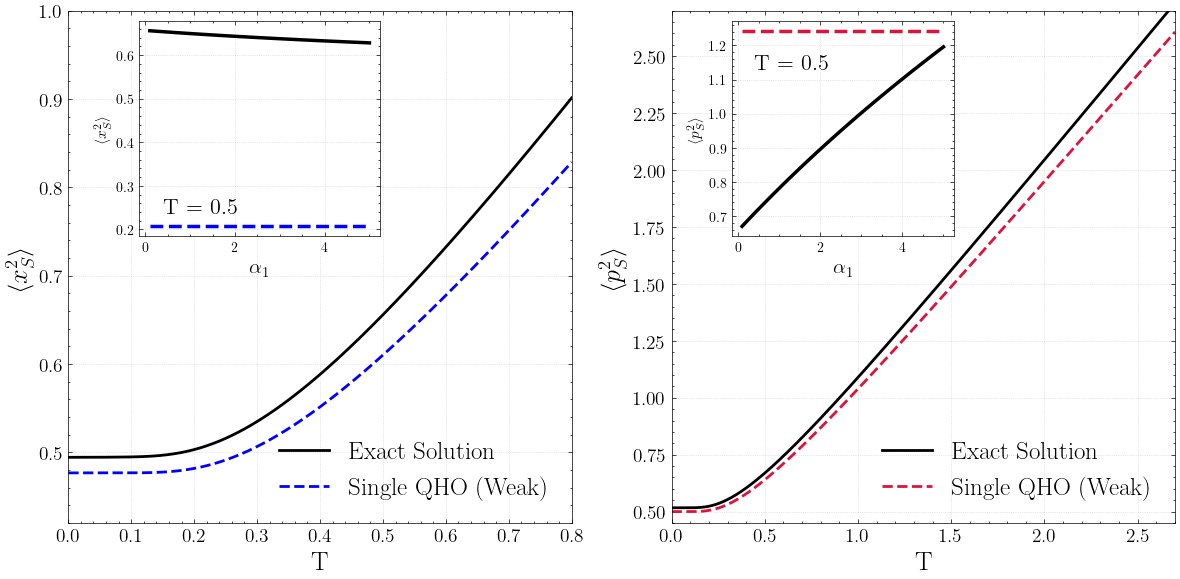